# Лабораторная работа 1: «Метод обратного распространения ошибки»

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_openml
def load_mnist():
    mnist = fetch_openml('mnist_784', version=1)
    X = mnist.data.astype('float32') / 255.0
    y = mnist.target.astype('int')
    
    X_train, X_test = X[:60000], X[60000:]
    y_train, y_test = y[:60000], y[60000:]
    
    return X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

X_train, X_test, y_train, y_test = load_mnist()

print("Размерности данных:")
print("Количество тренировочных примеров = ", X_train.shape[0] )
print("Количество тестовых примеров = ", X_test.shape[0])
print("Форма одного изображения = ", X_train[0].reshape(28, 28).shape)
print("Форма всех меток = ", y_train.shape)

Размерности данных:
Количество тренировочных примеров =  60000
Количество тестовых примеров =  10000
Форма одного изображения =  (28, 28)
Форма всех меток =  (60000,)


Демонстрация избранных изображений и меток классов для подтверждения корректности загрузки:


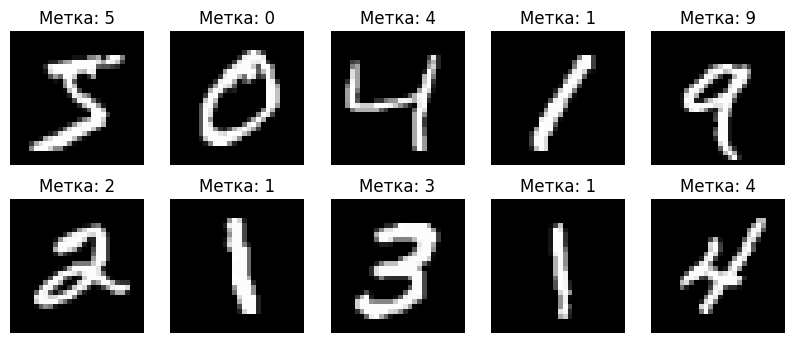

In [7]:
print("Демонстрация избранных изображений и меток классов для подтверждения корректности загрузки:")
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten() 

for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Метка: {y_train[i]}')
    ax.axis('off')
plt.show()

In [8]:
def initialize_parameters():
    
    input_size = 784
    hidden_size = 300
    output_size = 10
    
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
    b2 = np.zeros((1, output_size))
    
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

parameters = initialize_parameters()

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def forward(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    
    f = np.dot(X, W1) + b1      
    v = relu(f)               
    g = np.dot(v, W2) + b2    
    u = softmax(g)             
    
    cache = {"f": f, "v": v, "g": g, "u": u}
    return u, cache

def one_hot_encode(y, num_classes=10):
    y_encoded = np.zeros((y.size, num_classes))
    y_encoded[np.arange(y.size), y] = 1
    return y_encoded

def backward(X, y_true, params, cache):
    L = X.shape[0]
    W2 = params["W2"]
    v, u, f = cache["v"], cache["u"], cache["f"]

    d_g = u - y_true  
    d_W2 = np.dot(v.T, d_g) / L
    d_b2 = np.sum(d_g, axis=0, keepdims=True) / L
    
    d_v = np.dot(d_g, W2.T)
    d_f = d_v * relu_derivative(f) / L 
    d_W1 = np.dot(X.T, d_f) 
    d_b1 = np.sum(d_f, axis=0, keepdims=True) / L
    
    return {"W1": d_W1, "b1": d_b1, "W2": d_W2, "b2": d_b2}

def update_parameters(params, grads, learning_rate):
    for key in params:
        params[key] -= learning_rate * grads[key]
    return params

def classification_error(y_pred, y_true):
    predictions = np.argmax(y_pred, axis=1)
    return np.mean(predictions != y_true)

def train_network(X_train, y_train, parameters, 
                 epochs=20, batch_size=64, learning_rate=0.1):
    
    y_train_oh = one_hot_encode(y_train)
    n_train = X_train.shape[0]
    
    for epoch in range(epochs):
        start_time = time.time()
        
        index = np.random.permutation(n_train)
        X_mix = X_train[index]
        y_mix_oh = y_train_oh[index]
        y_mix = y_train[index]
        
        epoch_correct = 0
        
        for i in range(0, n_train, batch_size):
            X_batch = X_mix[i:i+batch_size]
            y_batch_oh = y_mix_oh[i:i+batch_size]
            y_batch = y_mix[i:i+batch_size]
            
            y_pred, cache = forward(X_batch, parameters)
            
            predictions = np.argmax(y_pred, axis=1)
            epoch_correct += np.sum(predictions == y_batch)
  
            grads = backward(X_batch, y_batch_oh, parameters, cache)
            parameters = update_parameters(parameters, grads, learning_rate)
        
        train_accuracy = epoch_correct / n_train
        train_classification_error = 1 - train_accuracy
                
        epoch_time = time.time() - start_time
        
        print(f"Эпоха {epoch+1:2d}/{epochs} | "
              f"Ошибка классификации: {train_classification_error:.4f} | "
              f"Время: {epoch_time:.2f}с")
    
    return parameters

trained_params = train_network(
    X_train, y_train,
    parameters,
    epochs=20,
    batch_size=64,
    learning_rate=0.1
)

Эпоха  1/20 | Ошибка классификации: 0.1002 | Время: 4.02с
Эпоха  2/20 | Ошибка классификации: 0.0529 | Время: 4.47с
Эпоха  3/20 | Ошибка классификации: 0.0400 | Время: 3.75с
Эпоха  4/20 | Ошибка классификации: 0.0316 | Время: 4.01с
Эпоха  5/20 | Ошибка классификации: 0.0260 | Время: 4.02с
Эпоха  6/20 | Ошибка классификации: 0.0217 | Время: 4.12с
Эпоха  7/20 | Ошибка классификации: 0.0190 | Время: 4.17с
Эпоха  8/20 | Ошибка классификации: 0.0159 | Время: 4.04с
Эпоха  9/20 | Ошибка классификации: 0.0145 | Время: 4.13с
Эпоха 10/20 | Ошибка классификации: 0.0129 | Время: 4.27с
Эпоха 11/20 | Ошибка классификации: 0.0111 | Время: 3.68с
Эпоха 12/20 | Ошибка классификации: 0.0100 | Время: 4.10с
Эпоха 13/20 | Ошибка классификации: 0.0085 | Время: 3.86с
Эпоха 14/20 | Ошибка классификации: 0.0072 | Время: 4.58с
Эпоха 15/20 | Ошибка классификации: 0.0066 | Время: 4.16с
Эпоха 16/20 | Ошибка классификации: 0.0057 | Время: 4.58с
Эпоха 17/20 | Ошибка классификации: 0.0051 | Время: 4.16с
Эпоха 18/20 | 

In [9]:
print("Результаты:")

test_predictions, _ = forward(X_test, trained_params)
final_test_error = classification_error(test_predictions, y_test)
final_accuracy = 1 - final_test_error

print(f"Ошибка классификации на тестовом наборе: {final_test_error:.4f}")
print(f"Точность на тестовом наборе: {final_accuracy*100:.2f}%")

Результаты:
Ошибка классификации на тестовом наборе: 0.0196
Точность на тестовом наборе: 98.04%


Демонстрация предсказаний на тестовых данных:


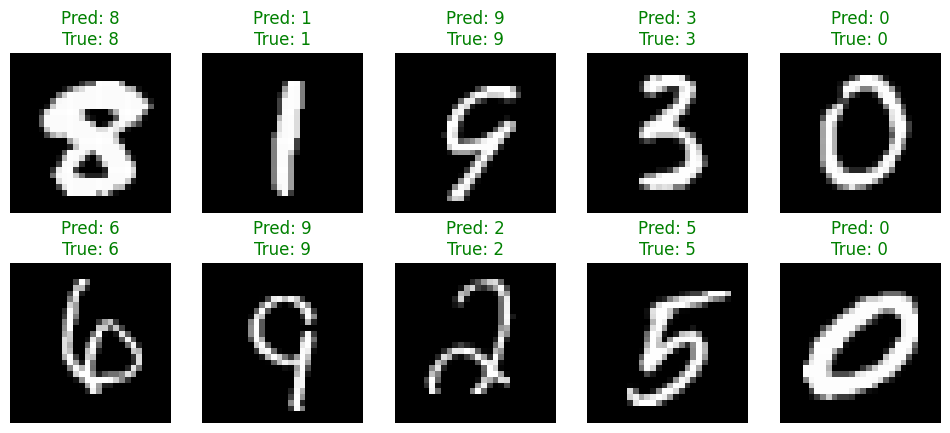

In [11]:
print("Демонстрация предсказаний на тестовых данных:")

index = np.random.choice(len(X_test), 10, replace=False)
X_samples = X_test[index]
y_true = y_test[index]

predictions, _ = forward(X_samples, trained_params)
y_pred = np.argmax(predictions, axis=1)

# Визуализация
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(X_samples[i].reshape(28, 28), cmap='gray')
    is_correct = y_pred[i] == y_true[i]
    color = 'green' if is_correct else 'red'
    ax.set_title(f'Pred: {y_pred[i]}\nTrue: {y_true[i]}', color=color)
    ax.axis('off')
plt.show()